# logistic regression Model

This notebook trains and evaluates a text-classification model for predicting the article category. It uses TF-IDF to represent article text numerically and logistic regression to predict the class probabilities.

The cells are arranged as a complete experiment: first the environment and data are prepared, then several model settings are compared, and finally the selected configuration is evaluated and used to create error-analysis files and a submission.



## 1. Setup

This section identifies the experiment and prepares the Python environment. The first code cell records the contributor and model name, the next cell makes the repository modules available both locally and in Google Colab, and the imports cell loads the libraries and project helpers used throughout the notebook.

In [1]:
MEMBER = "vestine umukundwa"
MODEL_NAME = "logistic_regression"

In [2]:
import os
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !git clone https://github.com/michael-alu/nlp_language_technologies.git
    %cd nlp_language_technologies
    %pip install -q -r requirements.txt

if Path.cwd().name == "notebooks":
    os.chdir("..")

sys.path.append(os.getcwd())
print("Working directory:", os.getcwd())

Cloning into 'nlp_language_technologies'...
remote: Enumerating objects: 333, done.
remote: Counting objects: 100% (333/333), done.
remote: Compressing objects: 100% (226/226), done.
remote: Total 333 (delta 138), reused 279 (delta 91), pack-reused 0 (from 0)
Receiving objects: 100% (333/333), 10.88 MiB | 17.74 MiB/s, done.
Resolving deltas: 100% (138/138), done.
/content/nlp_language_technologies
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 947.5/947.5 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.2/60.2 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 63.2 MB/s eta 0:00:00
Working directory: /content/nlp_language_technologies


In [3]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from src import config
from src import data_loading
from src import evaluation
from src import plots
from src.experiment_log import log_experiment
from src.reproducibility import FINAL_RUN_SEEDS, set_seed

## 2. Load the data

This cell loads the prepared training, validation, test, and competition datasets. It also converts category names into the numeric class IDs required by scikit-learn, combines training and validation data for cross-validation, and prints basic class and dataset-size checks so that loading problems or class imbalance are visible early.

In [4]:
train = data_loading.load_train()
validation = data_loading.load_validation()
test = data_loading.load_test()
zindi_test = data_loading.load_zindi_test()

train_ids = data_loading.labels_to_ids(train["category"])
validation_ids = data_loading.labels_to_ids(validation["category"])
test_ids = data_loading.labels_to_ids(test["category"])

# Used by cross-validation
train_and_validation = data_loading.load_train_and_validation()

print("Labels:", config.LABELS)
print("Sizes:", len(train), len(validation), len(test))
print(train["category"].value_counts())

Labels: ['kitaifa', 'michezo', 'biashara', 'kimataifa', 'burudani']
Sizes: 3603 772 773
category
kitaifa      1400
michezo      1203
biashara      951
kimataifa      38
burudani       11
Name: count, dtype: int64


## 3. The model

`build_model()` makes a TF-IDF + logistic regression pipeline. Each experiment just sets a `settings` dictionary; anything it does not set uses a sensible default. `run_experiment()` scores the settings on the validation split and with cross-validation, and logs both.

In [5]:
settings = {}  # Settings for the current experiment


def build_model():
    # Convert text into TF-IDF features
    vectorizer = TfidfVectorizer(
        analyzer=settings.get("analyzer", "word"),
        ngram_range=settings.get("ngram_range", (1, 1)),
        min_df=2,          # Ignore very rare words
        max_df=0.9,        # Ignore very common words
        sublinear_tf=True,
        lowercase=True,
    )

    # Create the classifier
    classifier = LogisticRegression(
        C=settings.get("C", 1.0),
        class_weight=settings.get("class_weight", None),
        max_iter=1000,
        solver="lbfgs",
        random_state=config.RANDOM_SEED,
    )

    # Combine TF-IDF and classifier
    return Pipeline([
        ("tfidf", vectorizer),
        ("classifier", classifier)
    ])


def run_experiment(name, notes):
    # Train and evaluate on validation data
    set_seed(config.RANDOM_SEED)
    model = build_model()
    model.fit(train["content"], train_ids)

    # Get predictions
    val_probs = model.predict_proba(validation["content"])

    # Calculate scores
    val_scores = evaluation.compute_scores(validation_ids, val_probs)
    evaluation.print_classification_report(validation_ids, val_probs)

    # Save validation results
    log_experiment(
        MEMBER, MODEL_NAME, name, "validation",
        settings, val_scores, notes
    )

    # Run cross-validation
    cv_scores = cross_validate(build_model, train_and_validation)

    # Save cross-validation results
    log_experiment(
        MEMBER, MODEL_NAME, name, "cross_validation",
        settings, cv_scores, notes
    )

    return model, val_probs, val_scores, cv_scores

## 4. Experiments

Compare settings using the **cross-validated** macro-F1, because the validation split has only 2 `burudani` articles, so one mistake changes the single-split score a lot.

### 4.1 Word unigrams (baseline) - how far do single words get?

This is the reference model. It represents each article using individual words only, so later configurations can be judged by whether they improve on this simple baseline.

In [6]:
from src.cross_validation import cross_validate
settings = {"analyzer": "word", "ngram_range": (1, 1)}
model, val_probs, val_scores, cv_scores = run_experiment("word_unigrams", "Single words only (baseline).")
val_scores

Random seed set to 42
              precision    recall  f1-score   support

     kitaifa       0.80      0.87      0.83       300
     michezo       0.94      0.96      0.95       258
    biashara       0.85      0.77      0.81       204
   kimataifa       0.00      0.00      0.00         8
    burudani       0.00      0.00      0.00         2

    accuracy                           0.86       772
   macro avg       0.52      0.52      0.52       772
weighted avg       0.85      0.86      0.86       772

Logged experiment 'word_unigrams' to /content/nlp_language_technologies/results/experiment_logs/logistic_regression.csv
===Fold 1: macro-F1 = 0.5244===
===Fold 2: macro-F1 = 0.5176===
===Fold 3: macro-F1 = 0.5143===
===Fold 4: macro-F1 = 0.5191===
===Fold 5: macro-F1 = 0.5121===
===Fold 6: macro-F1 = 0.5170===
===Fold 7: macro-F1 = 0.5253===
===Fold 8: macro-F1 = 0.5109===
===Fold 9: macro-F1 = 0.5196===
===Fold 10: macro-F1 = 0.5199===
===Fold 11: macro-F1 = 0.5228===
===Fold 12: mac

{'accuracy': 0.8614,
 'log_loss': 0.4373,
 'macro_f1': 0.5186,
 'weighted_f1': 0.8554,
 'f1_kitaifa': 0.8339,
 'f1_michezo': 0.95,
 'f1_biashara': 0.8093,
 'f1_kimataifa': 0.0,
 'f1_burudani': 0.0}

### 4.2 Add bigrams - do pairs like "Ligi Kuu" help?

This cell adds two-word sequences to the single-word features. Bigrams can preserve short phrases and word order, which may be more informative than either word by itself. Compare its cross-validated macro-F1 with the unigram baseline.

In [7]:
settings = {"analyzer": "word", "ngram_range": (1, 2)}
model, val_probs, val_scores, cv_scores = run_experiment("word_bigrams", "Words + word pairs (bigrams).")
val_scores

Random seed set to 42
              precision    recall  f1-score   support

     kitaifa       0.79      0.88      0.83       300
     michezo       0.95      0.95      0.95       258
    biashara       0.86      0.75      0.80       204
   kimataifa       0.00      0.00      0.00         8
    burudani       0.00      0.00      0.00         2

    accuracy                           0.86       772
   macro avg       0.52      0.52      0.52       772
weighted avg       0.85      0.86      0.85       772

Logged experiment 'word_bigrams' to /content/nlp_language_technologies/results/experiment_logs/logistic_regression.csv
===Fold 1: macro-F1 = 0.5224===
===Fold 2: macro-F1 = 0.5153===
===Fold 3: macro-F1 = 0.5109===
===Fold 4: macro-F1 = 0.5167===
===Fold 5: macro-F1 = 0.5116===
===Fold 6: macro-F1 = 0.5151===
===Fold 7: macro-F1 = 0.5221===
===Fold 8: macro-F1 = 0.5113===
===Fold 9: macro-F1 = 0.5155===
===Fold 10: macro-F1 = 0.5141===
===Fold 11: macro-F1 = 0.5168===
===Fold 12: macr

{'accuracy': 0.8575,
 'log_loss': 0.4701,
 'macro_f1': 0.516,
 'weighted_f1': 0.8515,
 'f1_kitaifa': 0.832,
 'f1_michezo': 0.9478,
 'f1_biashara': 0.8,
 'f1_kimataifa': 0.0,
 'f1_burudani': 0.0}

### 4.3 Character n-grams - do word pieces handle Swahili prefixes/suffixes better?

This experiment represents short character sequences inside word boundaries instead of complete words. Character n-grams can share information across related word forms, spelling variations, and prefixes or suffixes. The output shows whether that robustness improves the validation and cross-validation scores.

In [8]:
settings = {"analyzer": "char_wb", "ngram_range": (2, 5)}
model, val_probs, val_scores, cv_scores = run_experiment("char_ngrams", "Character n-grams (2-5).")
val_scores

Random seed set to 42
              precision    recall  f1-score   support

     kitaifa       0.80      0.88      0.84       300
     michezo       0.94      0.96      0.95       258
    biashara       0.86      0.77      0.81       204
   kimataifa       0.00      0.00      0.00         8
    burudani       0.00      0.00      0.00         2

    accuracy                           0.86       772
   macro avg       0.52      0.52      0.52       772
weighted avg       0.85      0.86      0.86       772

Logged experiment 'char_ngrams' to /content/nlp_language_technologies/results/experiment_logs/logistic_regression.csv
===Fold 1: macro-F1 = 0.5244===
===Fold 2: macro-F1 = 0.5206===
===Fold 3: macro-F1 = 0.5242===
===Fold 4: macro-F1 = 0.5150===
===Fold 5: macro-F1 = 0.5203===
===Fold 6: macro-F1 = 0.5228===
===Fold 7: macro-F1 = 0.5312===
===Fold 8: macro-F1 = 0.5163===
===Fold 9: macro-F1 = 0.5158===
===Fold 10: macro-F1 = 0.5255===
===Fold 11: macro-F1 = 0.5198===
===Fold 12: macro

{'accuracy': 0.864,
 'log_loss': 0.4314,
 'macro_f1': 0.5202,
 'weighted_f1': 0.8579,
 'f1_kitaifa': 0.8376,
 'f1_michezo': 0.95,
 'f1_biashara': 0.8135,
 'f1_kimataifa': 0.0,
 'f1_burudani': 0.0}

### 4.4 Balanced class weights - does weighting help `kimataifa` and `burudani`?

This run keeps the word-bigram representation but gives more influence to underrepresented classes during training. This tests whether correcting the class imbalance improves macro-F1, especially for the smaller categories, without relying only on overall accuracy.

In [9]:
settings = {"analyzer": "word", "ngram_range": (1, 2), "class_weight": "balanced"}
model, val_probs, val_scores, cv_scores = run_experiment("word_bigrams_balanced", "Bigrams + class_weight=balanced.")
val_scores

Random seed set to 42
              precision    recall  f1-score   support

     kitaifa       0.83      0.84      0.83       300
     michezo       0.95      0.95      0.95       258
    biashara       0.82      0.83      0.83       204
   kimataifa       1.00      0.25      0.40         8
    burudani       0.00      0.00      0.00         2

    accuracy                           0.87       772
   macro avg       0.72      0.57      0.60       772
weighted avg       0.86      0.87      0.86       772

Logged experiment 'word_bigrams_balanced' to /content/nlp_language_technologies/results/experiment_logs/logistic_regression.csv
===Fold 1: macro-F1 = 0.5531===
===Fold 2: macro-F1 = 0.5493===
===Fold 3: macro-F1 = 0.5596===
===Fold 4: macro-F1 = 0.5796===
===Fold 5: macro-F1 = 0.5846===
===Fold 6: macro-F1 = 0.5835===
===Fold 7: macro-F1 = 0.5530===
===Fold 8: macro-F1 = 0.5466===
===Fold 9: macro-F1 = 0.5631===
===Fold 10: macro-F1 = 0.5645===
===Fold 11: macro-F1 = 0.5519===
===Fold

{'accuracy': 0.8653,
 'log_loss': 0.5242,
 'macro_f1': 0.6011,
 'weighted_f1': 0.8625,
 'f1_kitaifa': 0.8325,
 'f1_michezo': 0.9478,
 'f1_biashara': 0.8252,
 'f1_kimataifa': 0.4,
 'f1_burudani': 0.0}

### 4.5 Tune C - how sensitive is the model to overfitting?

`C` controls the strength of logistic-regression regularization: smaller values constrain the model more, while larger values allow it to fit the training features more closely. The loop evaluates three values using the same balanced word-bigram pipeline and prints each cross-validated macro-F1 for comparison.

In [10]:
for c in [0.1, 1.0, 10.0]:
    settings = {"analyzer": "word", "ngram_range": (1, 2), "class_weight": "balanced", "C": c}
    print(f"\n========== C = {c} ==========")
    model, val_probs, val_scores, cv_scores = run_experiment(f"tune_C_{c}", f"Tuning C = {c}.")
    print(f"C = {c}  ->  CV macro-F1 = {cv_scores['macro_f1']}")


========== C = 0.1 ==========
Random seed set to 42
              precision    recall  f1-score   support

     kitaifa       0.85      0.78      0.82       300
     michezo       0.95      0.93      0.94       258
    biashara       0.77      0.90      0.83       204
   kimataifa       0.62      0.62      0.62         8
    burudani       0.00      0.00      0.00         2

    accuracy                           0.86       772
   macro avg       0.64      0.65      0.64       772
weighted avg       0.86      0.86      0.86       772

Logged experiment 'tune_C_0.1' to /content/nlp_language_technologies/results/experiment_logs/logistic_regression.csv
===Fold 1: macro-F1 = 0.5624===
===Fold 2: macro-F1 = 0.5781===
===Fold 3: macro-F1 = 0.5629===
===Fold 4: macro-F1 = 0.5822===
===Fold 5: macro-F1 = 0.5901===
===Fold 6: macro-F1 = 0.5656===
===Fold 7: macro-F1 = 0.6003===
===Fold 8: macro-F1 = 0.5704===
===Fold 9: macro-F1 = 0.6038===
===Fold 10: macro-F1 = 0.5794===
===Fold 11: macro-F1

### 4.6 Character n-grams + balanced class weights - do the best features also work best with weights?

*Added by Michael after reviewing the experiments above.*

Before weighting, character n-grams (4.3) had the best cross-validated macro-F1 and log loss of the three feature types, while bigrams (4.2) had the worst. Experiments 4.4 and 4.5 added class weights and tuned `C` on bigrams, so this run checks whether class weights work even better on top of the stronger character features.

In [11]:
settings = {"analyzer": "char_wb", "ngram_range": (2, 5), "class_weight": "balanced"}
model, val_probs, val_scores, cv_scores = run_experiment("char_ngrams_balanced", "Character n-grams (2-5) + class_weight=balanced.")
val_scores

Random seed set to 42
              precision    recall  f1-score   support

     kitaifa       0.83      0.83      0.83       300
     michezo       0.95      0.95      0.95       258
    biashara       0.82      0.83      0.82       204
   kimataifa       0.67      0.50      0.57         8
    burudani       0.00      0.00      0.00         2

    accuracy                           0.87       772
   macro avg       0.65      0.62      0.64       772
weighted avg       0.86      0.87      0.86       772

Logged experiment 'char_ngrams_balanced' to /content/nlp_language_technologies/results/experiment_logs/logistic_regression.csv
===Fold 1: macro-F1 = 0.6051===
===Fold 2: macro-F1 = 0.7092===
===Fold 3: macro-F1 = 0.6161===
===Fold 4: macro-F1 = 0.6277===
===Fold 5: macro-F1 = 0.6225===
===Fold 6: macro-F1 = 0.5913===
===Fold 7: macro-F1 = 0.6216===
===Fold 8: macro-F1 = 0.6896===
===Fold 9: macro-F1 = 0.6373===
===Fold 10: macro-F1 = 0.5492===
===Fold 11: macro-F1 = 0.7399===
===Fold 

{'accuracy': 0.8653,
 'log_loss': 0.4711,
 'macro_f1': 0.6354,
 'weighted_f1': 0.8643,
 'f1_kitaifa': 0.8314,
 'f1_michezo': 0.9498,
 'f1_biashara': 0.8244,
 'f1_kimataifa': 0.5714,
 'f1_burudani': 0.0}

### 4.7 Tune C for character n-grams + balanced class weights

*Added by Michael.*

The same `C` values as in 4.5, now on the character setup. `C = 1.0` is the default and was already tested in 4.6, so the loop only adds `C = 0.1` and `C = 10.0`.

In [12]:
for c in [0.1, 10.0]:
    settings = {"analyzer": "char_wb", "ngram_range": (2, 5), "class_weight": "balanced", "C": c}
    print(f"\n========== C = {c} ==========")
    model, val_probs, val_scores, cv_scores = run_experiment(f"char_balanced_C_{c}", f"Character n-grams + balanced, C = {c}.")
    print(f"C = {c}  ->  CV macro-F1 = {cv_scores['macro_f1']}")


========== C = 0.1 ==========
Random seed set to 42
              precision    recall  f1-score   support

     kitaifa       0.84      0.78      0.81       300
     michezo       0.95      0.91      0.93       258
    biashara       0.78      0.86      0.82       204
   kimataifa       0.31      0.62      0.42         8
    burudani       0.33      0.50      0.40         2

    accuracy                           0.84       772
   macro avg       0.64      0.74      0.67       772
weighted avg       0.85      0.84      0.85       772

Logged experiment 'char_balanced_C_0.1' to /content/nlp_language_technologies/results/experiment_logs/logistic_regression.csv
===Fold 1: macro-F1 = 0.7129===
===Fold 2: macro-F1 = 0.7440===
===Fold 3: macro-F1 = 0.5988===
===Fold 4: macro-F1 = 0.6187===
===Fold 5: macro-F1 = 0.5871===
===Fold 6: macro-F1 = 0.6148===
===Fold 7: macro-F1 = 0.7225===
===Fold 8: macro-F1 = 0.6731===
===Fold 9: macro-F1 = 0.5773===
===Fold 10: macro-F1 = 0.6632===
===Fold 11:

### Best configuration - inspect the errors

After comparing the experiment logs, set `settings` to the configuration with the strongest and most reliable cross-validated macro-F1. This cell reruns that choice, displays its validation scores, and draws a confusion matrix so we can see which categories are being confused before using the model on the test set.

**Decision (added by Michael): character n-grams (2-5), balanced class weights, `C = 1.0`.**

- Class weights were the biggest single improvement (4.4). Without them, the model never predicted `kimataifa` or `burudani`.
- With class weights, character n-grams beat word bigrams clearly (cross-validated macro-F1 0.633 vs 0.563, log loss 0.474 vs 0.534). Character pieces can match different forms of the same Swahili word (prefixes and suffixes), which whole-word features treat as unrelated words.
- For character n-grams, `C = 0.1` had about the same macro-F1 (0.636), but its log loss was almost twice as bad (0.905), because strong regularization makes the probabilities too uncertain. `C = 10.0` had the best log loss (0.355) but a lower macro-F1 (0.623), and its `kimataifa` F1 dropped from 0.45 to 0.29. `C = 1.0` is the best balance between the two metrics.

Random seed set to 42
              precision    recall  f1-score   support

     kitaifa       0.83      0.83      0.83       300
     michezo       0.95      0.95      0.95       258
    biashara       0.82      0.83      0.82       204
   kimataifa       0.67      0.50      0.57         8
    burudani       0.00      0.00      0.00         2

    accuracy                           0.87       772
   macro avg       0.65      0.62      0.64       772
weighted avg       0.86      0.87      0.86       772

Logged experiment 'best_config' to /content/nlp_language_technologies/results/experiment_logs/logistic_regression.csv
===Fold 1: macro-F1 = 0.6051===
===Fold 2: macro-F1 = 0.7092===
===Fold 3: macro-F1 = 0.6161===
===Fold 4: macro-F1 = 0.6277===
===Fold 5: macro-F1 = 0.6225===
===Fold 6: macro-F1 = 0.5913===
===Fold 7: macro-F1 = 0.6216===
===Fold 8: macro-F1 = 0.6896===
===Fold 9: macro-F1 = 0.6373===
===Fold 10: macro-F1 = 0.5492===
===Fold 11: macro-F1 = 0.7399===
===Fold 12: macro

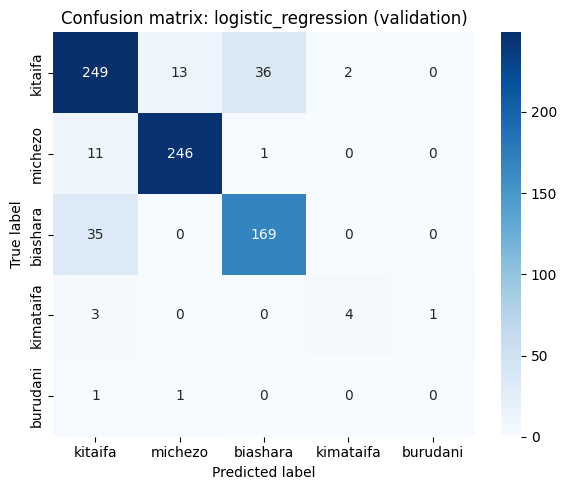

{'accuracy': 0.8653,
 'log_loss': 0.4711,
 'macro_f1': 0.6354,
 'weighted_f1': 0.8643,
 'f1_kitaifa': 0.8314,
 'f1_michezo': 0.9498,
 'f1_biashara': 0.8244,
 'f1_kimataifa': 0.5714,
 'f1_burudani': 0.0}

In [13]:
settings = {"analyzer": "char_wb", "ngram_range": (2, 5), "class_weight": "balanced", "C": 1.0}  # <-- set to your best
model, val_probs, val_scores, cv_scores = run_experiment("best_config", "Best settings from the experiments above.")

plots.plot_confusion_matrix(validation_ids, val_probs, MODEL_NAME, "validation")
val_scores

In [14]:
from src.experiment_log import EXPERIMENT_LOGS_DIRECTORY

def show_experiment_log():
    log = pd.read_csv(EXPERIMENT_LOGS_DIRECTORY / f"{MODEL_NAME}.csv")
    columns_to_show = ["experiment", "split", "macro_f1", "log_loss", "accuracy", "f1_kimataifa", "f1_burudani"]
    return log[columns_to_show].sort_values("macro_f1", ascending=False)

show_experiment_log()

,experiment,split,macro_f1,log_loss,accuracy,f1_kimataifa,f1_burudani
16,char_balanced_C_0.1,validation,0.6745,0.8972,0.8433,0.4167,0.4000
8,tune_C_0.1,validation,0.6428,1.0291,0.8588,0.6250,0.0000
17,char_balanced_C_0.1,cross_validation,0.6360,0.9052,0.8357,0.4357,0.2102
14,char_ngrams_balanced,validation,0.6354,0.4711,0.8653,0.5714,0.0000
20,best_config,validation,0.6354,0.4711,0.8653,0.5714,0.0000
15,char_ngrams_balanced,cross_validation,0.6326,0.4736,0.8649,0.4521,0.1044
21,best_config,cross_validation,0.6326,0.4736,0.8649,0.4521,0.1044
18,char_balanced_C_10.0,validation,0.6242,0.3734,0.8705,0.5000,0.0000
19,char_balanced_C_10.0,cross_validation,0.6234,0.3551,0.8735,0.2913,0.1933
6,word_bigrams_balanced,validation,0.6011,0.5242,0.8653,0.4000,0.0000


## 5. Final test (run once)

In [15]:
# Best model settings
settings = {
    "analyzer": "char_wb",
    "ngram_range": (2, 5),       # Use character pieces of 2 to 5 letters
    "class_weight": "balanced",  # Handle imbalanced classes
    "C": 1.0
}

# Set random seed
set_seed(config.RANDOM_SEED)

# Build the model
model = build_model()

# Train on the training data
model.fit(train["content"], train_ids)

# Predict probabilities on test data
test_probs = model.predict_proba(test["content"])

# Calculate test scores
test_scores = evaluation.compute_scores(test_ids, test_probs)

# Show classification results
evaluation.print_classification_report(test_ids, test_probs)

# Save the final results
log_experiment(
    MEMBER,
    MODEL_NAME,
    "final",
    "test",
    settings,
    test_scores,
    "Final model on the test set."
)

# Display the scores
test_scores

Random seed set to 42
              precision    recall  f1-score   support

     kitaifa       0.87      0.83      0.85       300
     michezo       0.95      0.93      0.94       258
    biashara       0.80      0.87      0.84       204
   kimataifa       0.44      0.50      0.47         8
    burudani       1.00      0.33      0.50         3

    accuracy                           0.87       773
   macro avg       0.81      0.69      0.72       773
weighted avg       0.87      0.87      0.87       773

Logged experiment 'final' to /content/nlp_language_technologies/results/experiment_logs/logistic_regression.csv


{'accuracy': 0.8706,
 'log_loss': 0.4649,
 'macro_f1': 0.7193,
 'weighted_f1': 0.8709,
 'f1_kitaifa': 0.8489,
 'f1_michezo': 0.9412,
 'f1_biashara': 0.8357,
 'f1_kimataifa': 0.4706,
 'f1_burudani': 0.5}

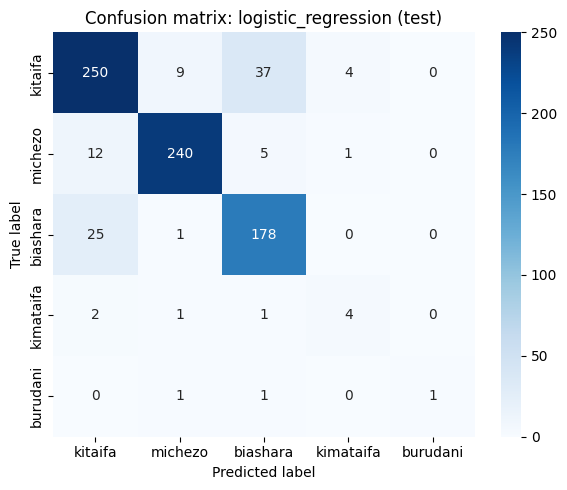

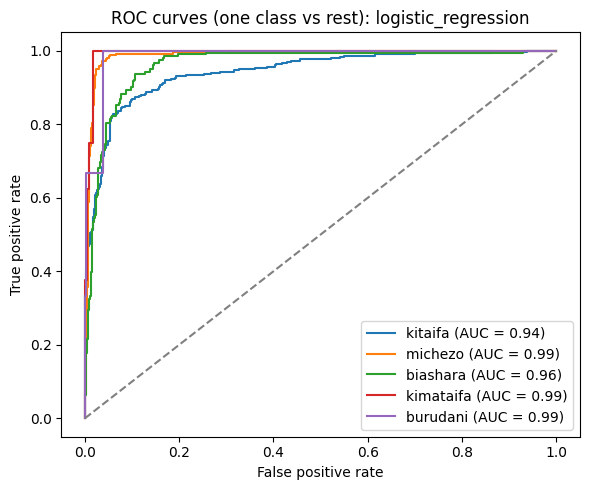

In [16]:
plots.plot_confusion_matrix(test_ids, test_probs, MODEL_NAME, "test")
plots.plot_roc_curves(test_ids, test_probs, MODEL_NAME, "test")

These plots provide a visual check of the final test predictions: the confusion matrix summarizes category-level mistakes, while the ROC curves show how well the predicted probabilities separate each class.

In [17]:
# Saves results/misclassified/logistic_regression.csv for the error analysis
evaluation.save_misclassified_examples(test, test_ids, test_probs, MODEL_NAME)

Saved 100 misclassified examples to /content/nlp_language_technologies/results/misclassified/logistic_regression.csv


In [18]:
zindi_probs = model.predict_proba(zindi_test["content"])
evaluation.save_zindi_submission(zindi_test, zindi_probs, MODEL_NAME)

Saved Zindi submission to /content/nlp_language_technologies/results/submissions/logistic_regression.csv
